<a href="https://colab.research.google.com/github/DABMASTER-Brought-me-into-this/ZeroToHeroColabCollection/blob/main/micrograd_from_scratch_yay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy
!pip install matplotlib

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline
# This line of code essentially displays plots directly below the code cell

In [ ]:
# Building the VALUE OBJECT :O
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = _children # Set() removes duplicates
    self._op = _op
    self.grad = 0
    self.label = label
    self._backward = lambda : None

  # What prints when u print d class
  def __repr__(self):
    return f"Value(data={self.data})"

  # All two var functions
  # When calling the add function in for ex: a + b. What internally is happening is a.__add__(b)
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward
    return out


  def __radd__(self, other):
    return self + other


  def __sub__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return self + other * -1;


  def __rsub__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return other - self

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out


  def __rmul__(self, other):
    return self * other


  def __truediv__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = self * other**-1
    return out


  def __rtruediv__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return other/self


  def __pow__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data ** other.data, (self,other), "**")

    def _backward():
      self.grad += (other.data * self.data ** (other.data-1)) * out.grad
      if self.data > 0:
          other.grad += np.log(self.data) * (self.data ** other.data) * out.grad
      else:
          other.grad += 0 # Cuz negiative values r not sigma

    out._backward = _backward
    return out


  # Single Functions
  def tanh(self):
    out = Value(np.tanh(self.data), (self,), "tanh")

    def _backward():
      self.grad += (1 - out.data**2) * out.grad

    out._backward = _backward
    return out


  def __neg__(self):
    return self * -1


  # Backwards Pass
  def backward(self):
    self.grad = 1
    topo = []
    visited = set()
    def build_topo(v: Value):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    for node in reversed(topo):
      node._backward()

  def reset_grad(self):
    self.grad = 1
    topo = []
    visited = set()
    def build_topo(v: Value):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    for node in reversed(topo):
      node.grad = 0

In [ ]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

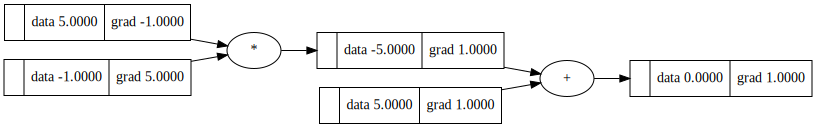

In [ ]:
a = Value(5)
b = a-5
b.backward()
draw_dot(b)

In [ ]:
# Neural Net
# Inputs
x1, x2 = Value(2.0, "x1"), Value(0, "x2")
# Weights
w1, w2 = Value(-3, "w1"), Value(1, "w2")
# Bias
b = Value(6.88137, "b")

x1w1 = x1*w1;x1w1.label = "x1w1"
x2w2 = x2*w2;x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [ ]:
# Neural Net
# Inputs
x1, x2 = Value(2.0, label="x1"), Value(0, label="x2")
# Weights
w1, w2 = Value(-3, label="w1"), Value(1, label="w2")
# Bias
b = Value(6.7, label="b")

x1w1 = x1*w1;x1w1.label = "x1w1"
x2w2 = x2*w2;x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

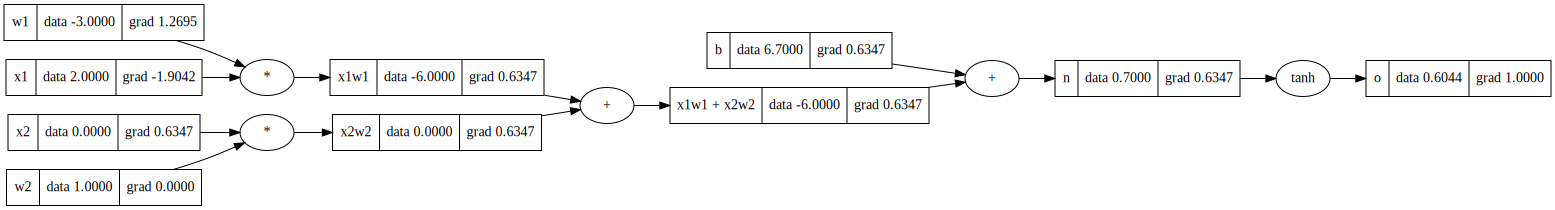

In [ ]:
draw_dot(o)

In [ ]:
o.backward()

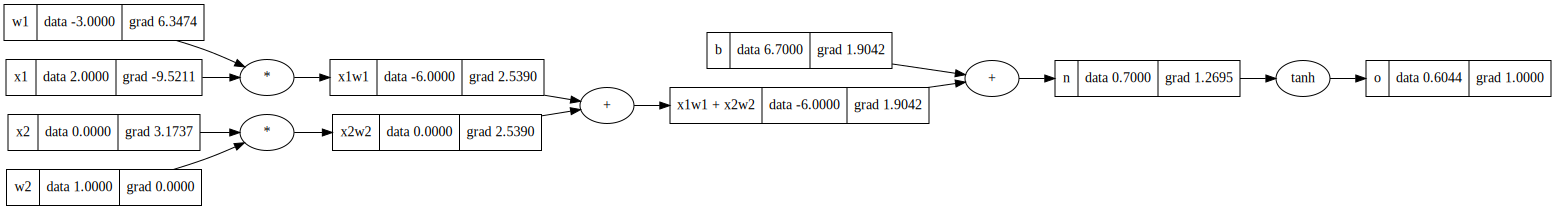

In [ ]:
draw_dot(o)

In [ ]:
import torch

In [ ]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.88137358]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()


print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())

0.7071066904050358
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
#BUILDING NEURONS
class Neuron:

  def __init__(self, nin):
    self.w =[Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))


  def __call__(self, x):
    act = sum(x1*w1 for x1, w1 in zip(self.w, x)) + self.b
    out = act.tanh()
    return out


  def parameters(self):
    return self.w + [self.b]
  # def all_weights(self):
  #   weights = {}
  #   for index, weight in enumerate(self.w):
  #     weights[index] = weight

  #   return weights


  # def all_bias(self):
  #   return {0: self.b}


#BUILDING LAYERS
class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  # def all_weights(self):
  #   weights = {}
  #   for index, neuron in enumerate(self.neurons):
  #     weights[index] = neuron.all_weights()

  #   return weights

  # def all_biases(self):
  #   biases = {}
  #   for index, neuron in enumerate(self.neurons):
  #     biases[index] = neuron.all_bias()

  #   return biases

  def parameters(self):
    params = []
    for neuron in self.neurons:
      ps = neuron.parameters()
      params.extend(ps)

    return params

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], (sz[i+1])) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x


  def parameters(self):
    params = []
    for layer in self.layers:
      ps = layer.parameters()
      params.extend(ps)

    return params

  # def all_weights(self):
  #   weights = {}
  #   for index, layer in enumerate(self.layers):
  #     weights[index] = layer.all_weights()

  #   return weights

  # def all_biases(self):
  #   biases = {}
  #   for index, layer in enumerate(self.layers):
  #     biases[index] = layer.all_biases()

  #   return biases

n = MLP(3, [4,4,1])

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
] # Inputs

ys = [1.0, -1.0, -1.0, 1.0] # Desired Output

In [ ]:
# Karpathy Way of Doing it

for k in range(20):
  # Forward Pass
  ypred = [n(x) for x in xs]
  loss = sum((act-pred)**2 for act,pred in zip(ys,ypred))

  # Backward Pass
  for p in n.parameters():
    p.grad = 0
  loss.backward()

  # Update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  # Info
  print(k, loss)

0 Value(data=5.679563266017604)
1 Value(data=2.8043812792423504)
2 Value(data=1.7871585188950285)
3 Value(data=1.0749106308651137)
4 Value(data=0.6047126740605834)
5 Value(data=0.37614622163547945)
6 Value(data=0.2625873439403626)
7 Value(data=0.19828311099776413)
8 Value(data=0.15785165845968635)
9 Value(data=0.13040206929302423)
10 Value(data=0.11068235739013309)
11 Value(data=0.0958965184031554)
12 Value(data=0.08443458832809417)
13 Value(data=0.0753099534626469)
14 Value(data=0.06788686519842851)
15 Value(data=0.061738449294516856)
16 Value(data=0.0565680856582635)
17 Value(data=0.0521636099074209)
18 Value(data=0.04836946391285388)
19 Value(data=0.04506912706762352)


In [ ]:
# # Try to Train A Neural Net From Scratch
# n = MLP(3, [4,4,1])
# loss = Value(1)
# while loss.data > 0.05:
#   ypred = [n(x) for x in xs]
#   print("YPred", ypred)
#   loss = sum((act-pred)**2 for act,pred in zip(ys,ypred)) # Calculating Forward Pass
#   # For the Satisfaction
#   print("Loss", loss)

#   loss.backward() # Assigning Weights & Biases Gradients

#   # Adjusting All Weights
#   all_weights = n.all_weights()
#   for layer_index, layer in all_weights.items():
#     for neuron_index, neuron in layer.items():
#       for weight_index, weight in neuron.items():
#         if weight.grad < 0:
#           n.layers[layer_index].neurons[neuron_index].w[weight_index].data += 0.001
#         else:
#           n.layers[layer_index].neurons[neuron_index].w[weight_index].data -= 0.001

#   # Adjusting All Biases
#   all_biases = n.all_biases()
#   for layer_index, layer in all_biases.items():
#     for neuron_index, neuron in layer.items():
#       for bias_index, bias in neuron.items():
#         if bias.grad < 0:
#           n.layers[layer_index].neurons[neuron_index].b.data += 0.001

#   # Resetting Gradients
#   loss.reset_grad()

#   # For the Satisfaction
#   print("-"*50)


# loss

In [ ]:
draw_dot(loss)

### NOT NEEDED ANYMORE ⬇️

In [ ]:
# Random function: 3x^2 - 4x + 5
def f(x):
  return 3*x**2 - 4*x + 5

In [ ]:
xs = np.arange(-5, 5, 0.1) # This function essentially is how our calculator plots it.
# It basically gets every point within a range n going by step to each point n draw the line b/n
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
def derivative(func, x):
  return (func(x+0.000001) - func(x))/0.000001

In [ ]:
derivative(f, 1)

In [ ]:
# Time for more complicated

#inputs
a = 2
b = -3
c = 10

def d(a,b,c):
  return a*b + c
# Derivative times
print("Derivative of d with respect to a", derivative(lambda x: d(x, b, c), a))
print("Derivative of d with respect to b", derivative(lambda x: d(a, x, c), b))
print("Derivative of d with respect to c", derivative(lambda x: d(a, b, x), c))

In [ ]:
## Building First Net
# In Neural Nets each Neuron has takens in a variety of inputs multiply them with varying weights, goes through an accumulation + bias and squash function and is output
# The squash function we will be doing today is tanh()

plt.plot(np.arange(-5,5,0.1), np.tanh(np.arange(-5,5,0.1)))

In [ ]:
L.grad = 1
d.grad = -2
f.grad = 4
c.grad = -2
e.grad = -2
b.grad = -2*2
a.grad = -3 * -2


# Given the gradients these changes should make L more positive
a.data += a.grad*0.001
f.data += f.grad*0.001

# Forwards Pass Again
e = a*b
d = e + c
L = d * f
L

In [ ]:
draw_dot(L)